In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from itertools import product

#seed = 42
#np.random.seed(seed)
#rng = np.random.default_rng(seed)

In [26]:
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
ds = [2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 200  # number of trials

In [27]:
def generate_gaus_data(v, n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v = np.concatenate([v * np.ones(n_neg),  np.ones(n_pos)])  # generate_v_data(n_neg, n_pos, rng)
    v_norm = v/sum(v)
    return X, y, v_norm

In [28]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200
sigma_pos = 1.0
sigma_neg = 1.0
mu_pos_scalar = 0.5 # class 1 mean
mu_neg_scalar = -0.5 # class -1 mean
vs = np.linspace(0.01, 1, 21) # different sigmas to run the experiments on

In [29]:
# run exact simulation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_v(t):
    dfs = []
    for d in ds:
        for v in vs:
            mu_pos =  np.concatenate(([mu_pos_scalar], np.zeros(d - 1)))
            mu_neg =  np.concatenate(([mu_neg_scalar], np.zeros(d - 1)))
            seed = hash((t, d, v)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v_vec = generate_gaus_data(v, n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d)
            #x_val, y_val, _ = generate_gaus_data(n_val_pos, n_val_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v_vec, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['v_neg'] = v / sum(v_vec)
            #df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

In [31]:
mega_df_v_less_1 = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_v)(t) for t in range(T)
        ), 
        ignore_index=True
)

alloc mid = 0
high, low 0.010802052389954086 0.010802052389954086
critical_v = None
iter = 9999
alloc mid = 0
high, low 0.005256173977147069 0.005256173977147069
critical_v = None
iter = 9999


In [30]:
mega_df_v.to_csv('mega_df_v.csv', index=False)

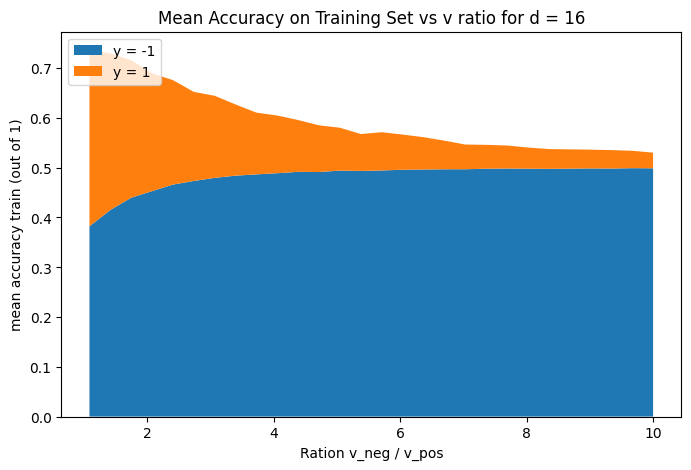

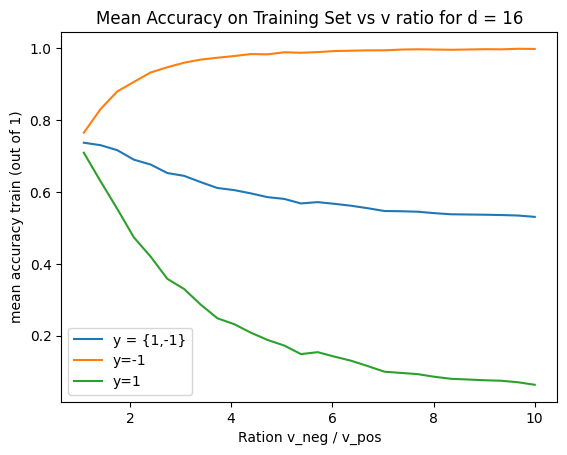

In [54]:
mega_df_v_filtered = mega_df_v[mega_df_v['v_neg'] >= 1]
stack_acc_v(mega_df_v_filtered, 'v_neg', d = 16)
plot_mean_accuracy_train_v(mega_df_v_filtered, 'v_neg', d = 16)

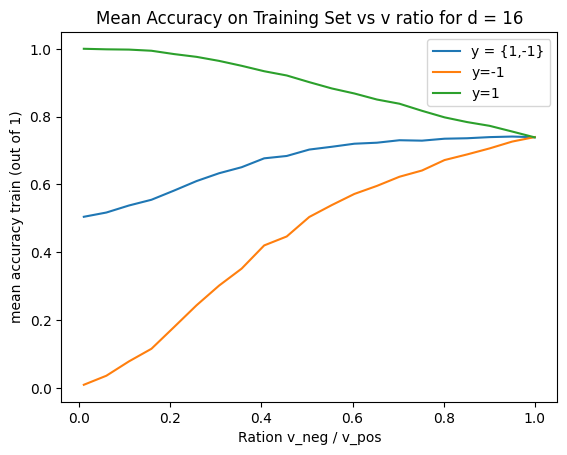

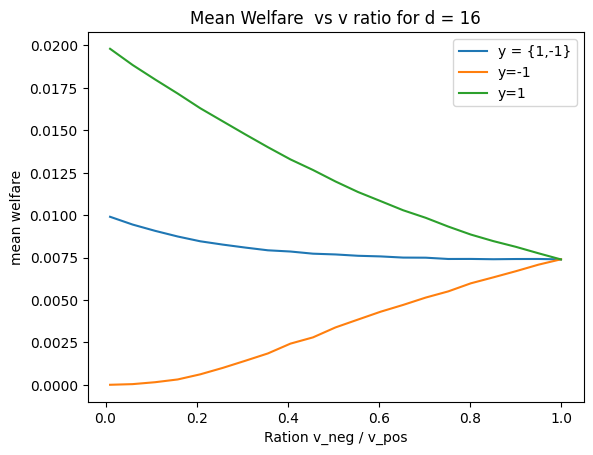

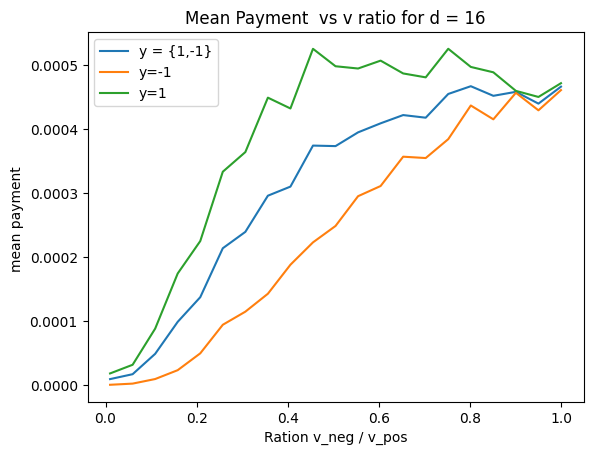

In [32]:
mega_df_v_filtered = mega_df_v_less_1[mega_df_v_less_1['v_neg'] < 1]
plot_mean_accuracy_train_v(mega_df_v_filtered, 'v_neg', d = 16)
plot_mean_welfare_v(mega_df_v_filtered, 'v_neg', d = 16)
plot_mean_payment_v(mega_df_v_filtered, 'v_neg', d = 16)

In [16]:
mega_df_v_filtered

,agent,allocation,true_v,critical_v,welfare,utility,is_relevant,support,is_throw,t,d,v_neg,label
300,0,1,0.010431,0.0,0.010431,0.010431,0,1,0,0,2,1.09,-1.0
301,1,1,0.010431,0.0,0.010431,0.010431,0,1,0,0,2,1.09,-1.0
302,2,1,0.010431,0.0,0.010431,0.010431,0,1,0,0,2,1.09,-1.0
303,3,1,0.010431,0.0,0.010431,0.010431,0,1,0,0,2,1.09,-1.0
304,4,1,0.010431,0.0,0.010431,0.010431,1,1,0,0,2,1.09,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719995,95,0,0.001818,0.0,0.000000,0.000000,0,0,0,199,64,10.00,1.0
3719996,96,0,0.001818,0.0,0.000000,0.000000,0,0,0,199,64,10.00,1.0
3719997,97,1,0.001818,0.0,0.001818,0.001818,0,1,0,199,64,10.00,1.0
3719998,98,0,0.001818,0.0,0.000000,0.000000,0,0,0,199,64,10.00,1.0


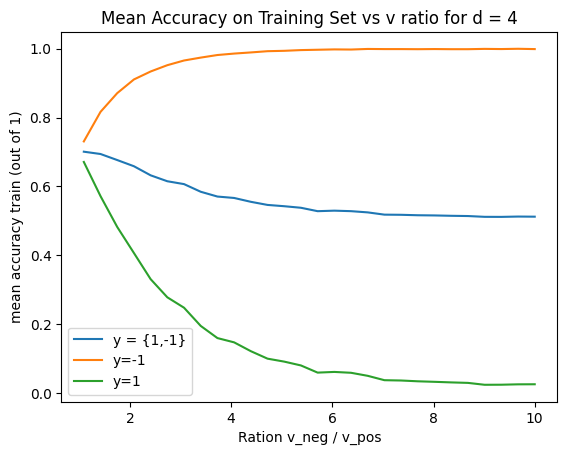

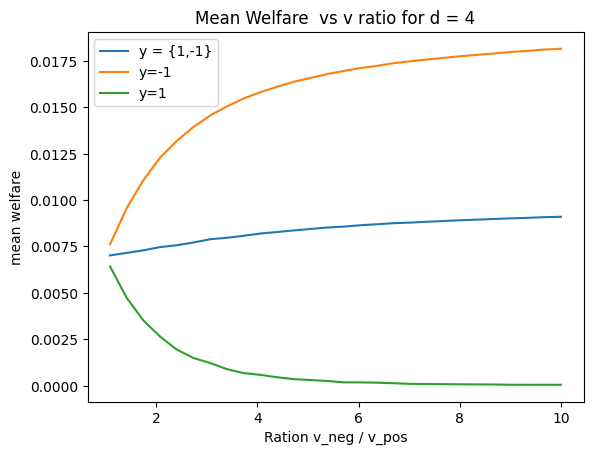

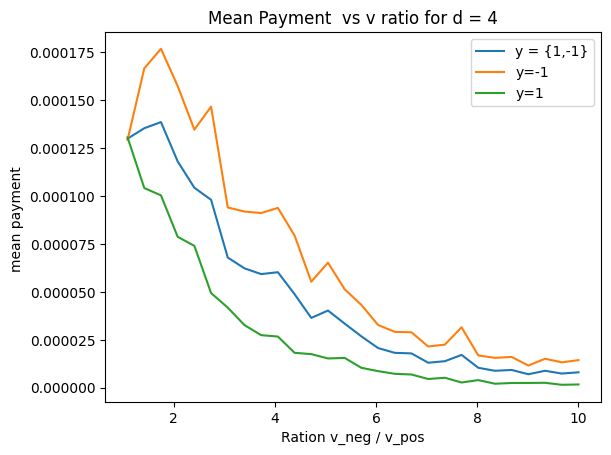

In [20]:
mega_df_v_filtered = mega_df_v[mega_df_v['v_neg'] >= 1]
plot_mean_accuracy_train_v(mega_df_v_filtered, 'v_neg', d = 4)
plot_mean_welfare_v(mega_df_v_filtered, 'v_neg', d = 4)
plot_mean_payment_v(mega_df_v_filtered, 'v_neg', d = 4)

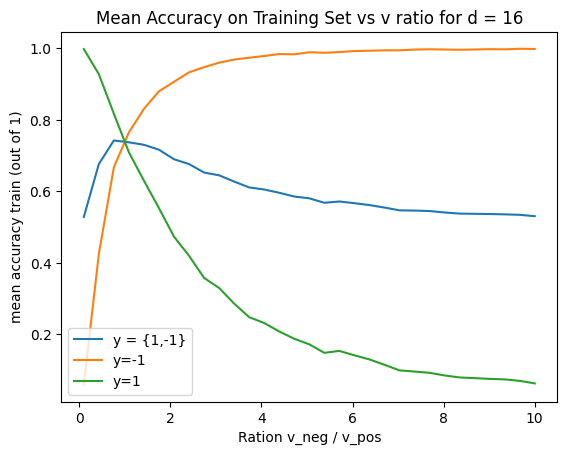

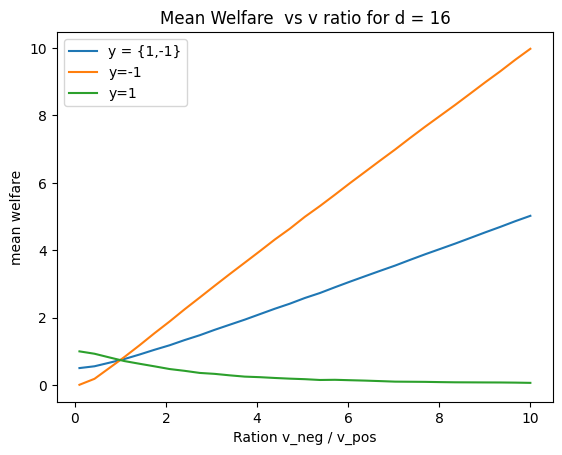

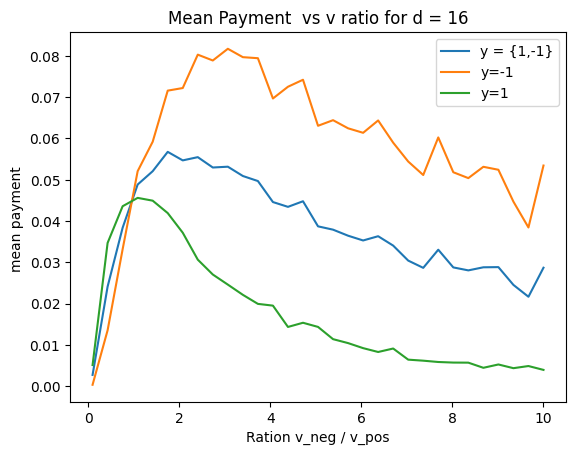

In [79]:
plot_mean_accuracy_train_v(mega_df_v, 'v_neg', d = 16)
plot_mean_welfare_v(mega_df_v, 'v_neg', d = 16)
plot_mean_payment_v(mega_df_v, 'v_neg', d = 16)

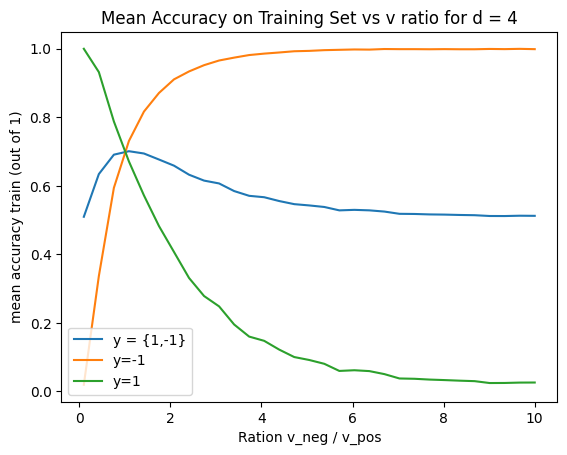

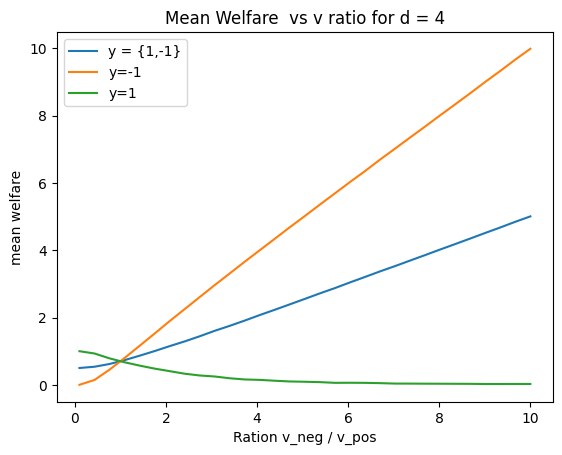

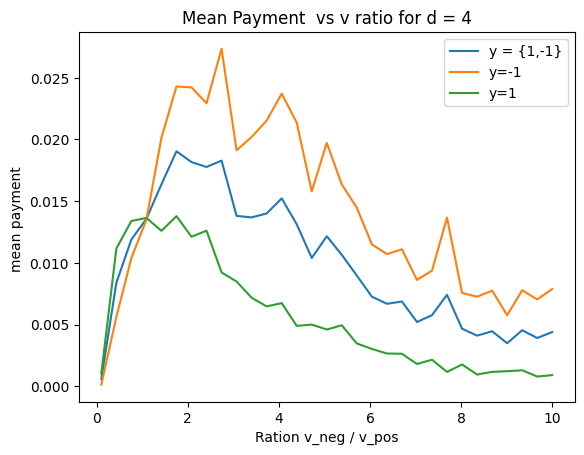

In [78]:
plot_mean_accuracy_train_v(mega_df_v, 'v_neg', d = 4)
plot_mean_welfare_v(mega_df_v, 'v_neg', d = 4)
plot_mean_payment_v(mega_df_v, 'v_neg', d = 4)